# Stage 8C.1 - Full Beam-to-Write Cockpit MVP

This notebook is an optical/energy/exposure cockpit. It does not predict material modification.

The purpose is to tune the editable source-to-sample lab chain, inspect real optical-field fluence diagnostics, and keep exposure bookkeeping visible while future material-response modules remain intentionally disabled.

## Notebook roadmap

Run the cells top to bottom:

1. **Set controls** - edit the single user-control cell below.
2. **Run the lab realism report** - stage-by-stage source-to-sample status.
3. **Acquire the real optical field** - from the repository engine (fails loudly if unavailable).
4. **Convert to fluence** - energy-scaled optical fluence (Mode B).
5. **Inspect the dashboard** - header status badge, beam-path strip, warning cards, XY / central ROI / XZ panels.
6. **Inspect the warnings** - captured-power drift, crop-edge peak, and feasibility flags.
7. **Interpret the claim boundary** - optical fluence only; material response is a future stage.

The large **DISPLAY TRUST** badge (PASS / CAUTION / FAIL) tells you at a glance whether the current optical/fluence display can be trusted.


In [1]:
# ============================================================
# FULL BEAM-TO-WRITE COCKPIT MVP - USER CONTROLS
# ============================================================

planning_mode = True
save_outputs = False
figure_dpi = 180
show_caveats = True
show_warnings = True
show_diagnostic_panels = True

# --- Simulation quality ---
engine_preset = "fast"          # fast | balanced | publication
engine_path = "ideal"           # ideal | realistic
require_real_field = True
allow_synthetic_demo_field = False

# --- Laser source ---
wavelength_nm = 1030.0
pulse_duration_fs = 260.0
repetition_rate_Hz = 25_000.0
pulse_energy_before_optics_uJ = 200.0
average_power_limit_W = 10.0
beam_radius_mm = 2.0
polarisation_state = "linear"

# --- Pre-SLM beam conditioning ---
pre_slm_transmission = 1.0
input_beam_radius_mm = 2.0
beam_ellipticity = 1.0
pointing_offset_x_um = 0.0
pointing_offset_y_um = 0.0
aperture_radius_mm = None

# --- Telescope / beam expander ---
telescope_enabled = False
telescope_magnification = 1.0
telescope_transmission = 1.0

# --- SLM1 phase / vortex ---
slm1_enabled = True
phase_profile = "vortex"
ell = 3
phase_quantisation_levels = 256
slm_pixel_pitch_um = 8.0
slm_active_width_px = None
slm_active_height_px = None
slm1_diffraction_efficiency = 0.95

# --- SLM2 / axicon / holography ---
generation_method = "holographic"    # holographic | physical
target_core_diameter_um = 3.0
target_bessel_length_um = 150.0
axicon_k_r = None
blaze_period_px = 20
slm2_diffraction_efficiency = 0.95
slm2_conjugate_mode = "preserve_vortex"
physical_axicon_enabled = False
physical_axicon_angle_deg = None

# --- First-order filtering ---
first_order_filter_enabled = True
selected_first_order_fraction = 0.73
filter_radius_px_or_lpmm = None
zero_order_leakage_fraction = 0.0

# --- Relay optics ---
relay_transmission = 0.90
relay_magnification = 1.0
relay_aberration_enabled = False

# --- Objective and pupil ---
objective_NA = 0.45
objective_transmission = 0.85
objective_effective_focal_length_mm = None
objective_pupil_diameter_mm = None
pupil_diameter_override_mm = None

# --- Sample/interface ---
material_name = "Cr:ZnSe"
refractive_index = 2.44
sample_thickness_mm = 5.0
focus_depth_um = 100.0
sample_interface_transmission = 0.95
use_fresnel_interface_estimate = False
surface_tilt_mrad = 0.0

# --- In-sample propagation / field stack ---
grid_N = None
device_downsample = None
axial_planes = None
crop_window_um = None

# --- Field/fluence display ---
selected_z_um = "target_depth"       # target_depth | optical_peak | sample_surface | custom
selected_z_mode = selected_z_um
custom_z_um = 100.0
central_roi_half_width_um = 10.0
display_scaling = "percentile"       # linear | log | percentile
display_percentile_clip = (0.5, 99.5)
fluence_normalisation_mode = "per_plane_transverse_energy"

# --- Writing plan / exposure bookkeeping ---
writing_mode = "line_x"              # static_single | static_multi | line_x | line_y | line_z | tilted_line | disabled
scan_axis = "x"
scan_speed_mm_s = 1.0
line_length_um = 500.0
effective_diameter_um = 3.0
num_static_pulses = 100
num_passes = 1
z_step_um = 0.0
tilt_angle_deg = 0.0

# --- Future physics toggles: must remain disabled in Stage 8C.1 ---
enable_material_response = False
enable_threshold_proxy = False
enable_dose_accumulation = False
enable_nonlinear_proxy = False
enable_thermal_proxy = False
enable_microscope_proxy = False
enable_calibrated_prediction = False


## 1. Purpose and claim boundary

This notebook is an optical/energy/exposure cockpit. It does not predict material modification. It scales real optical-field intensity arrays to optical fluence, reports energy throughput, and performs exposure bookkeeping only.

In [2]:
# Guard rails for saving, demo fields, and future physics toggles.
if save_outputs and not show_caveats:
    raise ValueError("Cannot save Stage 8C.1 outputs with show_caveats=False.")

future_flags = {
    "enable_material_response": enable_material_response,
    "enable_threshold_proxy": enable_threshold_proxy,
    "enable_dose_accumulation": enable_dose_accumulation,
    "enable_nonlinear_proxy": enable_nonlinear_proxy,
    "enable_thermal_proxy": enable_thermal_proxy,
    "enable_microscope_proxy": enable_microscope_proxy,
    "enable_calibrated_prediction": enable_calibrated_prediction,
}
if any(future_flags.values()):
    enabled = [name for name, value in future_flags.items() if value]
    raise NotImplementedError(f"Stage 8C.1 does not implement future physics toggles: {enabled}")
if allow_synthetic_demo_field and save_outputs:
    raise ValueError("unit_test_or_demo_only fields cannot be saved as governed outputs.")

CAVEAT_TEXT = (
    "This is an optical/energy/exposure cockpit. It does not model absorption, "
    "material modification, ablation, cracks, voids, waveguides, nonlinear propagation, "
    "or thermal accumulation. Energy-scaled fluence is optical fluence only."
)
if show_caveats:
    print(CAVEAT_TEXT)


This is an optical/energy/exposure cockpit. It does not model absorption, material modification, ablation, cracks, voids, waveguides, nonlinear propagation, or thermal accumulation. Energy-scaled fluence is optical fluence only.


In [3]:
# ============================================================
# RUNTIME CHECK + AUTORELOAD + INLINE BACKEND
# Prevents two failure modes:
#   1. stale import / wrong path -> notebook renders the OLD dashboard
#   2. matplotlib.use("Agg") in the modules -> display(fig) shows NO image inline
# ============================================================
import os
import sys
import inspect
from pathlib import Path

# Enable autoreload so edits to vbb_study are picked up without a manual kernel restart.
try:
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("load_ext", "autoreload")
        _ip.run_line_magic("autoreload", "2")
except Exception:
    pass

# Make sure the local Publication_Study package wins on sys.path.
for _cand in [Path.cwd(), *Path.cwd().parents]:
    if (_cand / "bessel_twin_core.py").is_file():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        break

# Import the digital-twin modules first. They call matplotlib.use("Agg") at import,
# so we re-enable the inline backend AFTERWARDS to guarantee figures render in-notebook.
import vbb_study
import vbb_study.digital_twin.cockpit_dashboard as cd
try:
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

print("Python    :", sys.executable)
print("CWD       :", os.getcwd())
print("vbb_study :", Path(vbb_study.__file__).resolve())
print("cockpit   :", Path(cd.__file__).resolve())
print("has compute_overall_status :", hasattr(cd, "compute_overall_status"))
print("has build_beam_path_strip  :", hasattr(cd, "build_beam_path_strip"))
print("dashboard is Stage 8C.2    :", "DISPLAY TRUST" in inspect.getsource(cd))

# Fail loudly if a stale module is loaded so we never silently render the old dashboard.
assert hasattr(cd, "compute_overall_status"), "Stale cockpit_dashboard import - restart the kernel."
assert "DISPLAY TRUST" in inspect.getsource(cd), "Old dashboard loaded - restart kernel / check path."

Python    : C:\PhD\.venv2\Scripts\python.exe
CWD       : C:\PhD\Code\Publication_Study\notebooks\digital_twin
vbb_study : C:\PhD\Code\Publication_Study\vbb_study\__init__.py
cockpit   : C:\PhD\Code\Publication_Study\vbb_study\digital_twin\cockpit_dashboard.py
has compute_overall_status : True
has build_beam_path_strip  : True
dashboard is Stage 8C.2    : True


In [4]:
from pathlib import Path
import sys
import numpy as np

_root = Path.cwd()
for _candidate in [Path.cwd(), *Path.cwd().parents]:
    if (_candidate / "bessel_twin_core.py").is_file():
        _root = _candidate
        break
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from vbb_study.digital_twin.field_coupling import (
    MissingOpticalFieldError,
    extract_plane_from_surfacefield,
    extract_stack_from_surfacefield,
    plane_from_arrays,
)
from vbb_study.digital_twin.field_fluence import scale_plane_to_fluence, scale_stack_to_fluence
from vbb_study.digital_twin.lab_realism_controls import (
    build_energy_ledger_from_controls,
    build_exposure_summary_from_controls,
    build_lab_realism_report,
)
from vbb_study.digital_twin.cockpit_dashboard import (
    compute_peak_location_diagnostics,
    build_warning_flags,
    plot_integrated_cockpit_dashboard,
    make_interpretation_text,
)


## 2. User controls

All editable controls are in the first code cell.

In [5]:
control_names = [
    "planning_mode", "save_outputs", "figure_dpi", "show_caveats", "show_warnings", "show_diagnostic_panels",
    "engine_preset", "engine_path", "require_real_field", "allow_synthetic_demo_field",
    "wavelength_nm", "pulse_duration_fs", "repetition_rate_Hz", "pulse_energy_before_optics_uJ", "average_power_limit_W", "beam_radius_mm", "polarisation_state",
    "pre_slm_transmission", "input_beam_radius_mm", "beam_ellipticity", "pointing_offset_x_um", "pointing_offset_y_um", "aperture_radius_mm",
    "telescope_enabled", "telescope_magnification", "telescope_transmission",
    "slm1_enabled", "phase_profile", "ell", "phase_quantisation_levels", "slm_pixel_pitch_um", "slm_active_width_px", "slm_active_height_px", "slm1_diffraction_efficiency",
    "generation_method", "target_core_diameter_um", "target_bessel_length_um", "axicon_k_r", "blaze_period_px", "slm2_diffraction_efficiency", "slm2_conjugate_mode", "physical_axicon_enabled", "physical_axicon_angle_deg",
    "first_order_filter_enabled", "selected_first_order_fraction", "filter_radius_px_or_lpmm", "zero_order_leakage_fraction",
    "relay_transmission", "relay_magnification", "relay_aberration_enabled",
    "objective_NA", "objective_transmission", "objective_effective_focal_length_mm", "objective_pupil_diameter_mm", "pupil_diameter_override_mm",
    "material_name", "refractive_index", "sample_thickness_mm", "focus_depth_um", "sample_interface_transmission", "use_fresnel_interface_estimate", "surface_tilt_mrad",
    "grid_N", "device_downsample", "axial_planes", "crop_window_um",
    "selected_z_um", "selected_z_mode", "custom_z_um", "central_roi_half_width_um", "display_scaling", "display_percentile_clip", "fluence_normalisation_mode",
    "writing_mode", "scan_axis", "scan_speed_mm_s", "line_length_um", "effective_diameter_um", "num_static_pulses", "num_passes", "z_step_um", "tilt_angle_deg",
    "enable_material_response", "enable_threshold_proxy", "enable_dose_accumulation", "enable_nonlinear_proxy", "enable_thermal_proxy", "enable_microscope_proxy", "enable_calibrated_prediction",
]
controls = {name: globals()[name] for name in control_names}


## 3. Stage-by-stage lab realism report

The `LabRealismReport` is the central source-to-sample table: every stage reports editable inputs, computed outputs, warnings, missing metrics, and handoff.

In [6]:
ledger = build_energy_ledger_from_controls(controls)
exposure_summary = build_exposure_summary_from_controls(
    controls,
    pulse_energy_at_sample_uJ=ledger.energy_at_sample_uJ,
    repetition_rate_Hz=repetition_rate_Hz,
)
lab_report = build_lab_realism_report(controls, energy_ledger=ledger, exposure_summary=exposure_summary)
lab_report.to_dataframe()


,stage_name,enabled,key_inputs,key_outputs,model_status,status_level,warnings,missing_metrics,handoff_to_next_stage
0,laser_source,True,wavelength_nm=1030; pulse_duration_fs=260; rep...,average_power_before_optics_W=5; power_limit_s...,energy_accounting_prediction,pass,,,pulse energy and source metadata to pre-SLM co...
1,pre_slm_beam_conditioning,True,pre_slm_transmission=1; input_beam_radius_mm=2...,energy_after_pre_slm_uJ=200; beam_radius_at_sl...,energy_accounting_prediction,missing,,aperture clipping not available from current e...,conditioned beam radius and energy to telescop...
2,telescope_or_beam_expander,False,telescope_enabled=False; telescope_magnificati...,beam_radius_after_telescope_mm=2; energy_after...,energy_accounting_prediction,diagnostic_only,,,beam radius and energy to SLM1
3,slm1_phase,True,slm1_enabled=True; phase_profile=vortex; ell=3...,slm_sampling_status=active area not available ...,optical_prediction,pass,,SLM active area not available from current engine,vortex/phase state and energy to SLM2 route
4,slm2_phase_or_axicon,True,generation_method=holographic; axicon_k_r=None...,route_status=holographic route; measured_topol...,optical_prediction,pass,,measured topological winding not available fro...,routed diffracted field to first-order filtering
5,first_order_filter,True,first_order_filter_enabled=True; selected_firs...,carrier_frequency_lpmm=not available from curr...,optical_prediction,pass,,carrier/cone frequency not available from curr...,selected diffraction order to relay optics
6,relay_optics,True,relay_transmission=0.9; relay_magnification=1;...,energy_after_relay_uJ=computed in energy ledge...,energy_accounting_prediction,pass,,,relayed beam to objective pupil
7,objective_and_pupil,True,objective_NA=0.45; objective_transmission=0.85...,pupil_radius_mm=not available from current eng...,optical_prediction,missing,,objective pupil diameter not available from cu...,focused field to sample interface
8,sample_interface,True,material_name=Cr:ZnSe; refractive_index=2.44; ...,fresnel_normal_incidence_transmission=0.8248; ...,energy_accounting_prediction,pass,,,sample-entered optical field to propagation stack
9,in_sample_propagation,True,engine_preset=fast; engine_path=ideal; grid_N=...,field_source_status=not available from current...,optical_prediction,fail,real field is required by controls,real optical field summary not available from ...,real optical intensity stack to fluence scaling


## 4. Experiment request summary

In [7]:
experiment_request = {
    "laser": f"{wavelength_nm} nm, {pulse_duration_fs} fs, {repetition_rate_Hz} Hz",
    "route": f"{generation_method} VBB, ell={ell}",
    "slm_settings": f"SLM1 {phase_profile}; SLM2 {slm2_conjugate_mode}; blaze={blaze_period_px} px",
    "optical_chain": f"first order={selected_first_order_fraction}, relay={relay_transmission}, objective={objective_transmission}",
    "sample": f"{material_name}, n={refractive_index}, focus depth={focus_depth_um} um",
    "writing_plan": f"{writing_mode}, {scan_speed_mm_s} mm/s, {line_length_um} um",
    "selected_visual_plane": selected_z_um,
}
experiment_request


{'laser': '1030.0 nm, 260.0 fs, 25000.0 Hz',
 'route': 'holographic VBB, ell=3',
 'slm_settings': 'SLM1 vortex; SLM2 preserve_vortex; blaze=20 px',
 'optical_chain': 'first order=0.73, relay=0.9, objective=0.85',
 'sample': 'Cr:ZnSe, n=2.44, focus depth=100.0 um',
 'writing_plan': 'line_x, 1.0 mm/s, 500.0 um',
 'selected_visual_plane': 'target_depth'}

## 5. Energy ledger

In [8]:
print(f"Pulse energy before optics: {pulse_energy_before_optics_uJ:.4g} uJ")
print(f"Energy at sample: {ledger.energy_at_sample_uJ:.4g} uJ")
print(f"Average power at sample: {ledger.average_power_at_sample_W:.4g} W")
print(f"Cumulative throughput: {ledger.total_throughput_fraction:.2%}")
for row in ledger.rows:
    print(f"{row.component_name:30s} {row.energy_in_uJ:9.4g} -> {row.energy_out_uJ:9.4g} uJ  frac={row.fraction_this_component:.3g}")
for warning in ledger.ledger_warnings:
    print("WARNING:", warning)


Pulse energy before optics: 200 uJ
Energy at sample: 95.76 uJ
Average power at sample: 2.394 W
Cumulative throughput: 47.88%
pre_slm_beam_conditioning            200 ->       200 uJ  frac=1
telescope_or_beam_expander           200 ->       200 uJ  frac=1
slm1_phase                           200 ->       190 uJ  frac=0.95
slm2_phase_or_axicon                 190 ->     180.5 uJ  frac=0.95
first_order_filter                 180.5 ->     131.8 uJ  frac=0.73
relay_optics                       131.8 ->     118.6 uJ  frac=0.9
objective_and_pupil                118.6 ->     100.8 uJ  frac=0.85
sample_interface                   100.8 ->     95.76 uJ  frac=0.95


## 6. Lab realism / hardware feasibility panel

Energy/power limit, first-order geometry, pupil fill/clipping, SLM sampling/downsampling, route validity, crop-window/captured-power drift, peak near edge, pulse overlap, and material-response availability are all shown as pass/caution/fail/missing/disabled states.

In [9]:
warning_flags = build_warning_flags(energy_ledger=ledger, exposure_summary=exposure_summary)
warning_flags


{'captured_power_drift': {'status': 'pass',
  'message': 'raw captured-power drift acceptable'},
 'crop_edge_peak': {'status': 'pass',
  'message': 'global peak is not near crop edge'},
 'first_order_geometry': {'status': 'pass',
  'message': 'first-order geometry valid'},
 'pupil_clipping': {'status': 'pass',
  'message': 'pupil clipping not detected'},
 'power_limit': {'status': 'pass',
  'message': 'average power within configured limit'},
 'pulse_overlap': {'status': 'pass',
  'message': 'pulse spacing supports continuous scan bookkeeping'}}

## 7. Real optical field acquisition

Use the real repository engine. If no governed optical field is available and `require_real_field=True`, fail loudly. A labelled `unit_test_or_demo_only` branch exists only for local notebook wiring checks and refuses saving.

In [10]:
surface_field = None
volume = None
field_source_status = "not loaded"

try:
    import bessel_twin_core as bt
    engine_result = bt.run_case(preset=engine_preset, path=engine_path, case_id="stage8c1_integrated_cockpit")
    surface_field = engine_result.get("surface_field")
    volume = engine_result.get("volume")
    field_source_status = "real_optical_field"
except Exception as exc:
    field_source_status = f"engine unavailable: {exc}"
    print(field_source_status)

if volume is None and require_real_field and not allow_synthetic_demo_field:
    raise MissingOpticalFieldError("No real optical volume available; refusing to fabricate a production field.")

if volume is None and allow_synthetic_demo_field:
    save_outputs = False
    print("unit_test_or_demo_only: synthetic demonstration field is labelled and cannot be saved.")
    n = 64
    z_demo = np.linspace(0.0, 150.0, 5)
    x_demo = (np.arange(n) - (n - 1) / 2.0) * 0.5
    X, Y = np.meshgrid(x_demo, x_demo, indexing="xy")
    stack_demo = []
    for zval in z_demo:
        R = np.hypot(X, Y)
        stack_demo.append(np.exp(-(R ** 2) / (2 * 3.0 ** 2)) * (1.0 + 0.1 * zval / max(z_demo)))
    volume = {"intensity_stack": np.asarray(stack_demo), "z": z_demo * 1e-6, "crop_grid": {"x": x_demo * 1e-6, "y": x_demo * 1e-6}}

stack = extract_stack_from_surfacefield(volume)
plane = extract_plane_from_surfacefield(surface_field, preferred_z_um=0.0) if surface_field is not None else None
print("field_source_status:", field_source_status)
print("stack:", stack.intensity_zyx.shape, "dx_um", stack.dx_um, "dy_um", stack.dy_um)


field_source_status: real_optical_field
stack: (41, 192, 192) dx_um 0.25 dy_um 0.25


## 8. Field-to-fluence scaling

This section reports selected plane, central ROI peak, target-depth peak, sample-surface peak, peak intensity estimate, propagation/crop captured-power drift, global peak diagnostics, and edge/corner peak warning.

In [11]:
fluence_stack = scale_stack_to_fluence(stack, ledger.energy_at_sample_uJ)
fluence_plane = scale_plane_to_fluence(plane, ledger.energy_at_sample_uJ) if plane is not None else None
diagnostics = compute_peak_location_diagnostics(
    stack,
    fluence_stack,
    target_depth_um=focus_depth_um,
    central_roi_half_width_um=central_roi_half_width_um,
    selected_z_mode=selected_z_mode,
    custom_z_um=custom_z_um,
    pulse_duration_fs=pulse_duration_fs,
)
field_summary = {
    "source_status": stack.source_status,
    "dx_um": stack.dx_um,
    "dy_um": stack.dy_um,
    "propagation_energy_drift_fraction": fluence_stack.propagation_energy_drift_fraction,
}
lab_report = build_lab_realism_report(
    controls,
    energy_ledger=ledger,
    exposure_summary=exposure_summary,
    field_summary=field_summary,
    diagnostics=diagnostics,
)
warning_flags = build_warning_flags(energy_ledger=ledger, exposure_summary=exposure_summary, diagnostics=diagnostics)
diagnostics


{'global_peak_value': 160.0045310344464,
 'global_peak_x_um': -23.874999999999996,
 'global_peak_y_um': -23.874999999999996,
 'global_peak_z_um': -102.99987874555738,
 'global_peak_index_zyx': (0, 0, 0),
 'global_peak_distance_to_boundary_px': 0,
 'global_peak_near_boundary': True,
 'central_roi_peak_value': 94.58366495104889,
 'central_roi_peak_x_um': 0.125,
 'central_roi_peak_y_um': -2.625,
 'central_roi_peak_z_um': 65.7501212544426,
 'central_roi_peak_index_zyx': (18, 85, 96),
 'central_roi_peak_by_z_j_cm2': array([2.35506212e-01, 1.04616773e-01, 3.91371672e-02, 2.06217036e-02,
        3.98030494e-02, 6.87743870e-02, 2.96272375e-01, 1.66129768e+00,
        6.22294790e+00, 6.25701753e+00, 6.57561082e+00, 9.04899234e+00,
        3.16880298e+01, 5.00317037e+01, 6.63789467e+01, 7.89254376e+01,
        8.75535629e+01, 9.27445361e+01, 9.45836650e+01, 9.36850473e+01,
        9.01664713e+01, 8.52055400e+01, 7.90131991e+01, 7.21162862e+01,
        6.50131785e+01, 5.86332554e+01, 5.24526577e+

## 9. Exposure bookkeeping

This is exposure bookkeeping, not material response.

In [12]:
for key, value in exposure_summary.items():
    print(f"{key}: {value}")


pulse_spacing_um: 0.04
pulses_per_spot: 75.0
dose_per_unit_length_J_m: 2394.00534375
line_duration_s: 0.5
total_pulses_on_line: 12500
total_energy_on_line_uJ: 1197002.671875
overlap_fraction: 0.9866666666666667
model_status: exposure_bookkeeping
final_export_allowed: False
warnings: []


## 10. Main integrated cockpit dashboard figure

The integrated dashboard shows experiment summary, energy ledger, exposure bookkeeping, lab realism status, XY intensity, XY fluence, central ROI zoom, XZ fluence with surface/target/selected/peak markers, peak fluence by z, raw captured-power drift, warnings, caveats, and disabled future physics.

overall display-trust status: caution


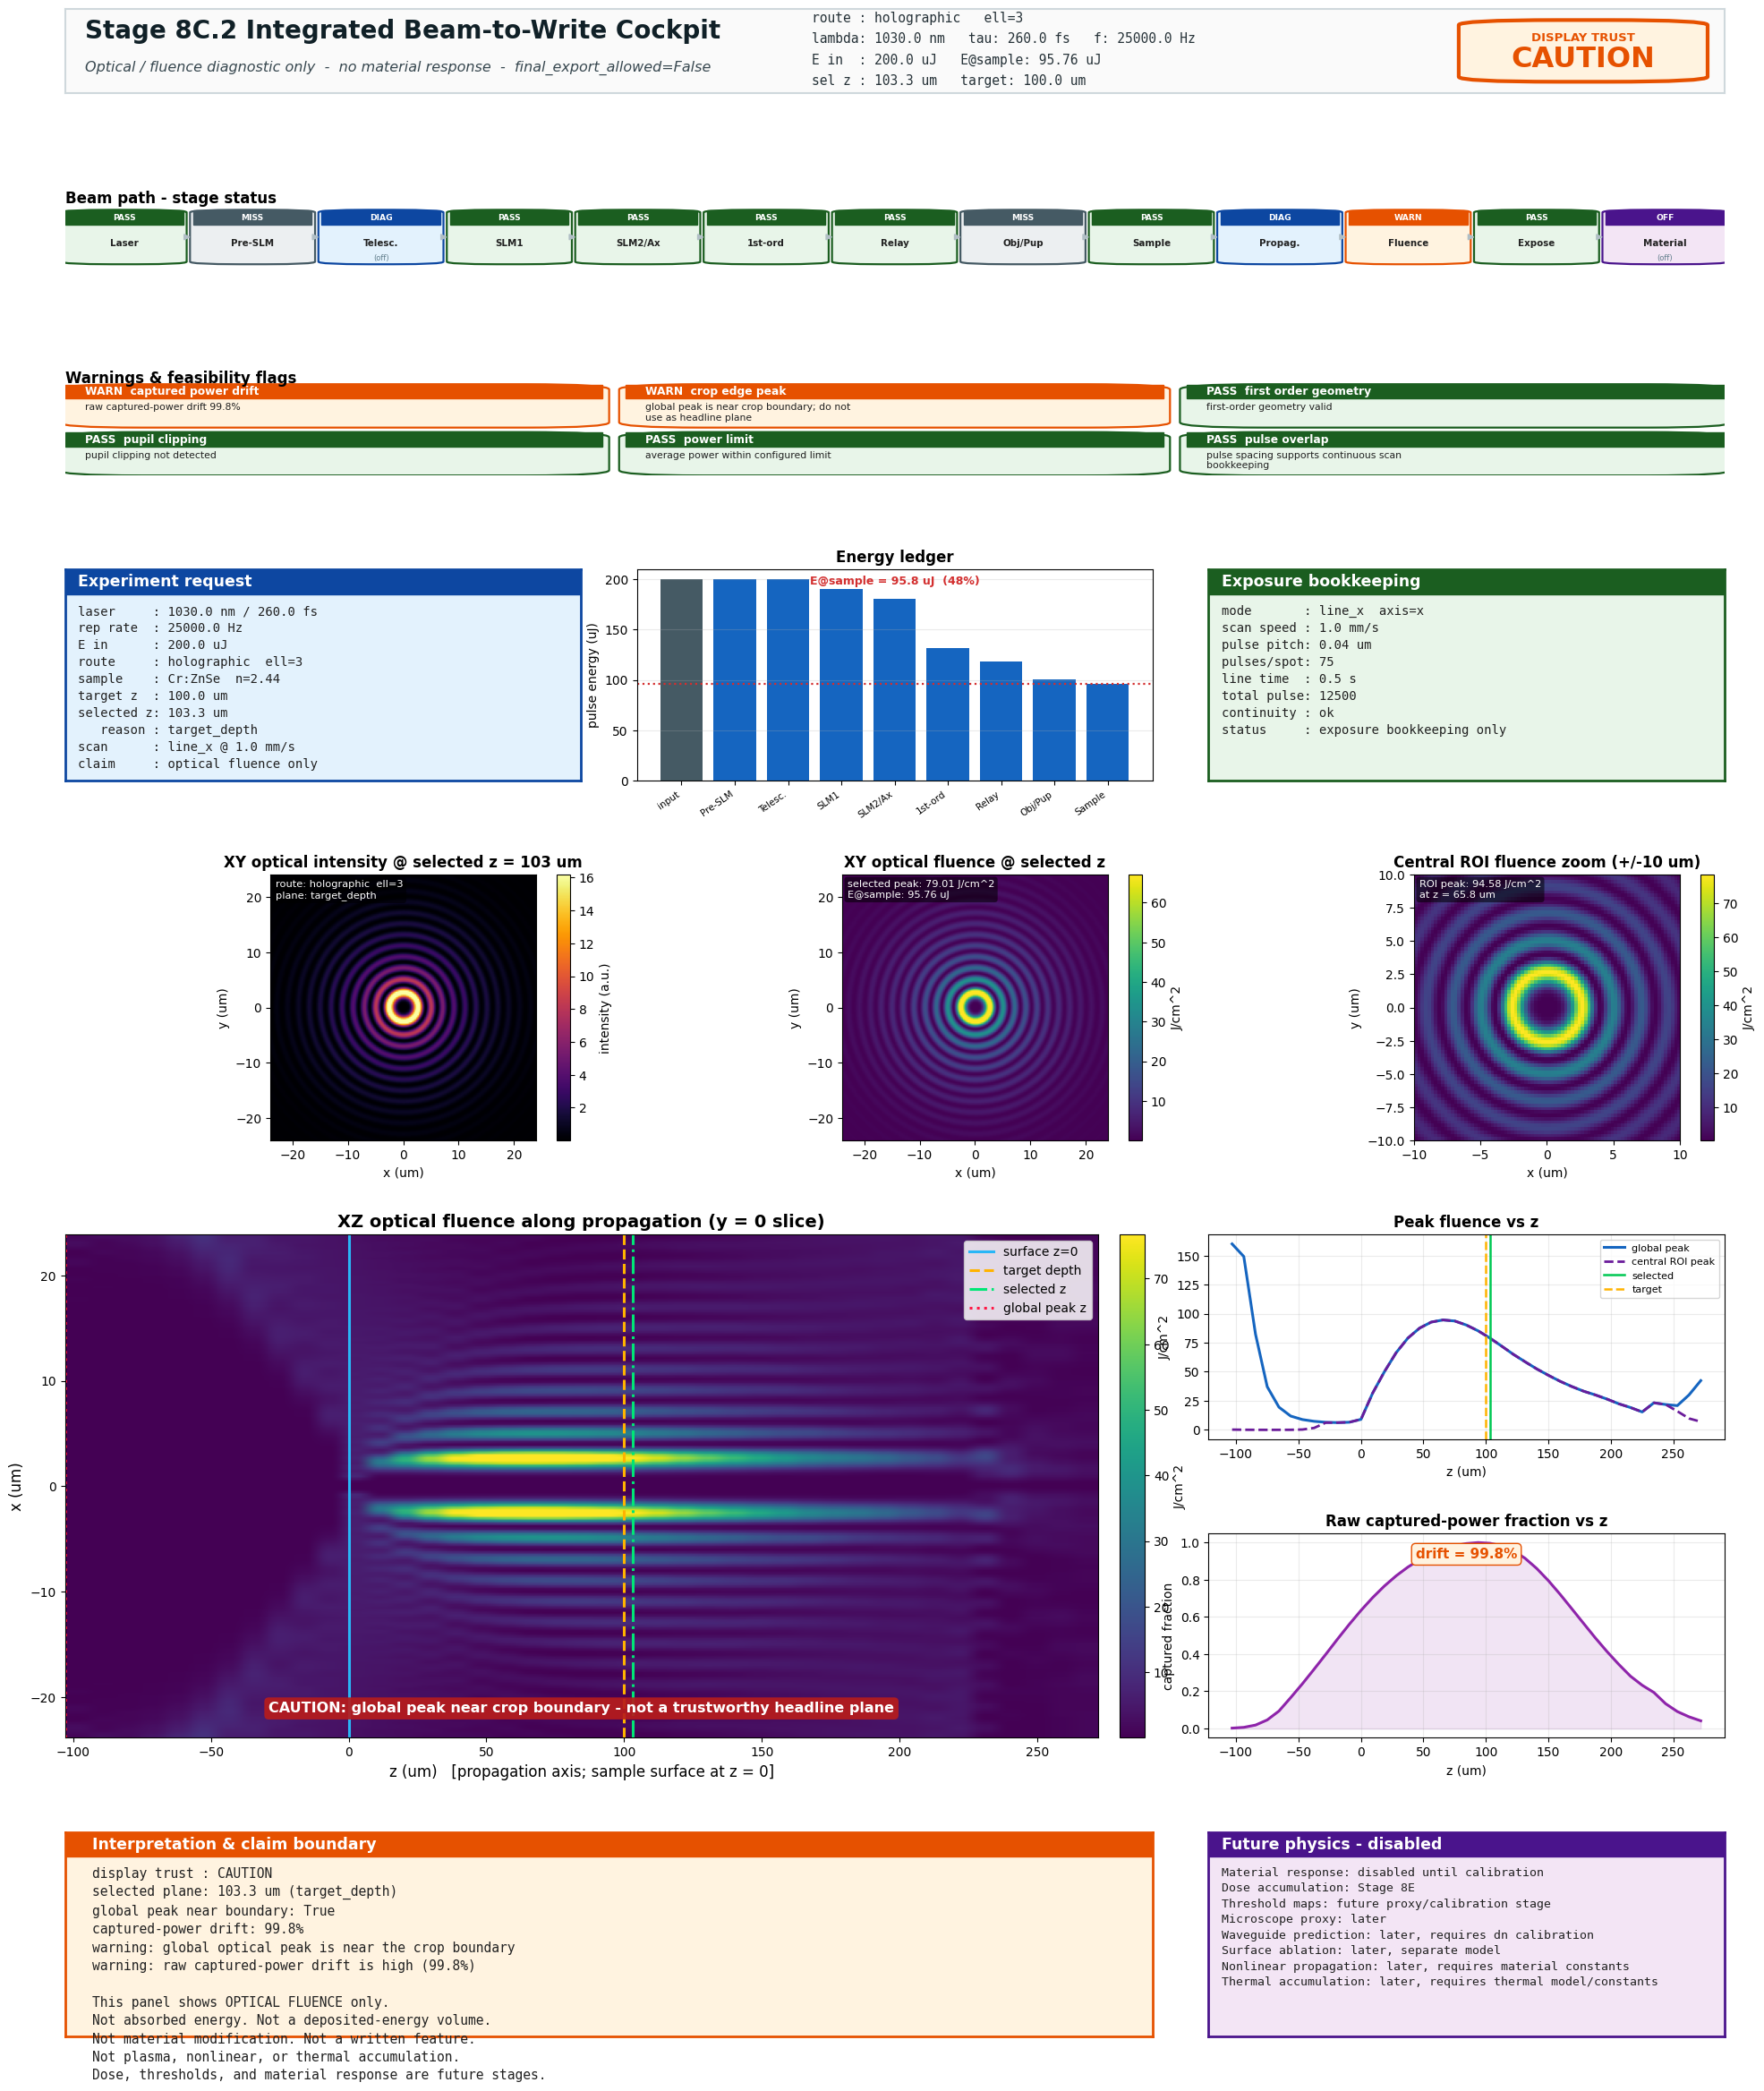

In [13]:
from IPython.display import display
import matplotlib.pyplot as plt

output_path = _root / "outputs" / "figures" / "digital_twin" / "stage8c2_integrated_cockpit_dashboard_preview.png"
fig = plot_integrated_cockpit_dashboard(
    stack,
    fluence_stack,
    controls=controls,
    energy_ledger=ledger,
    exposure_summary=exposure_summary,
    lab_report=lab_report,
    diagnostics=diagnostics,
    output_path=output_path if save_outputs else None,
    show_caveats=show_caveats,
    dpi=figure_dpi,
    display_scaling=display_scaling,
    display_percentile_clip=display_percentile_clip,
)
print("overall display-trust status:", fig.stage8c2_metadata["overall_status"])
# Render exactly one inline copy; close before cell end to avoid a duplicate auto-render.
display(fig)
plt.close(fig)
plt.show()

## 11. Interpretation panel

In [14]:
print(make_interpretation_text(
    controls=controls,
    energy_ledger=ledger,
    exposure_summary=exposure_summary,
    diagnostics=diagnostics,
    lab_report=lab_report,
))


Energy at sample is 95.76 uJ from 200.0 uJ before optics.
Average power is below the configured limit; sample average power is 2.394 W.
The optical route is valid.
The first-order geometry is valid.
Pupil fill/clipping status is not available from current engine.
Pulse spacing is 0.04 um, giving 75 pulses per spot.
For the selected plane, peak optical fluence is 79.01 J/cm^2.
Central ROI peak is 94.58 J/cm^2.
Target-depth peak is 79.01 J/cm^2.
Peak intensity estimate is 6.154e+14 W/cm^2, assuming no nonlinear reshaping.
The global field peak is near the crop boundary.
Captured-power drift is 99.80%.
Lab realism status is caution.
This output is optical fluence only; no material modification is predicted.


## 12. Disabled future physics panels

Material response: disabled until calibration

Dose accumulation: Stage 8E

Threshold maps: future proxy/calibration stage

Microscope proxy: later

Waveguide prediction: later, requires dn calibration

Surface ablation: later, separate model

Nonlinear propagation: later, requires material constants

Thermal accumulation: later, requires thermal model/constants

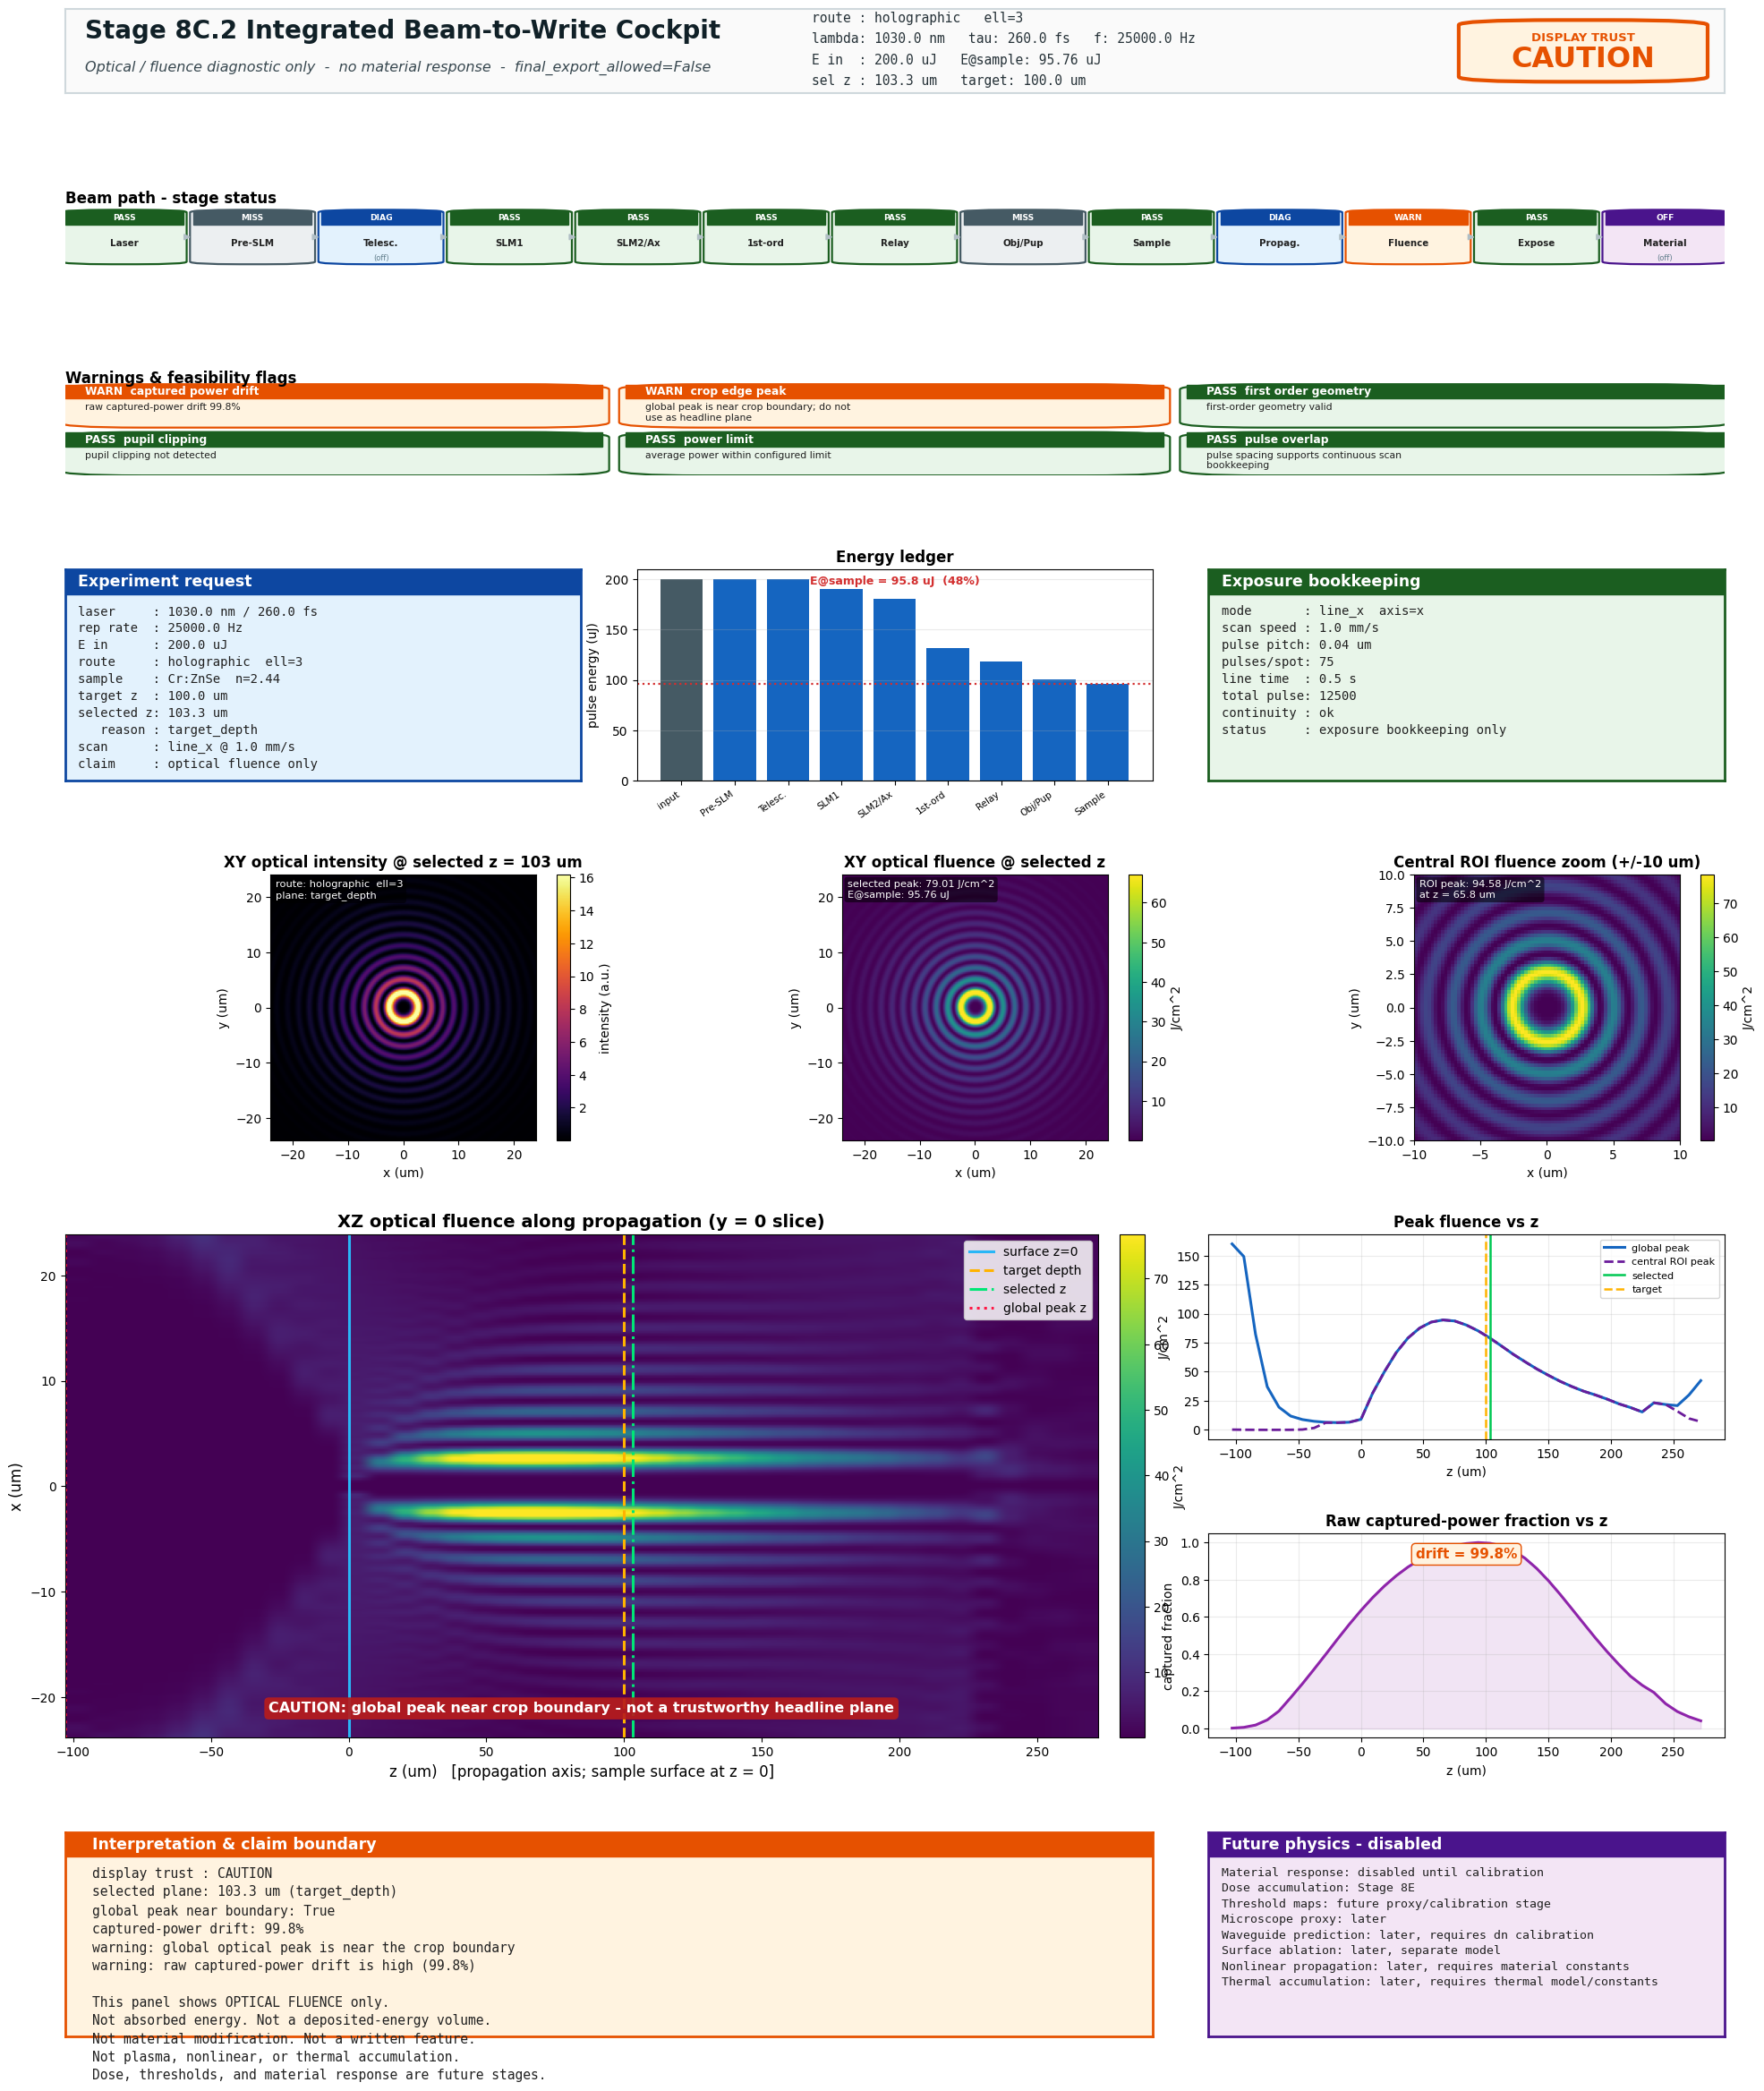

Saved diagnostic preview (final_export_allowed=False) to:
C:\PhD\Code\Publication_Study\outputs\figures\digital_twin\stage8c2_integrated_cockpit_dashboard_preview.png


In [15]:
# ============================================================
# FINAL VISUAL CHECK - confirm the dashboard rendered and save a diagnostic preview
# ============================================================
from IPython.display import display
import matplotlib.pyplot as plt

assert "fig" in globals() and fig is not None, "Cockpit dashboard figure was not created."
assert fig.stage8c2_metadata["final_export_allowed"] is False, "Dashboard must be diagnostic only."

# Show the dashboard again (single inline copy).
display(fig)
plt.show()

preview_path = _root / "outputs" / "figures" / "digital_twin" / "stage8c2_integrated_cockpit_dashboard_preview.png"
# A diagnostic preview (final_export_allowed=False) is saved only with caveats on and only for a
# real/governed field - never for a unit_test_or_demo_only field.
if show_caveats and stack.source_status != "unit_test_or_demo_only":
    _saved = plot_integrated_cockpit_dashboard(
        stack, fluence_stack, controls=controls, energy_ledger=ledger,
        exposure_summary=exposure_summary, lab_report=lab_report, diagnostics=diagnostics,
        output_path=preview_path, show_caveats=show_caveats, dpi=figure_dpi,
        display_scaling=display_scaling, display_percentile_clip=display_percentile_clip,
    )
    plt.close(_saved)
    print("Saved diagnostic preview (final_export_allowed=False) to:")
    print(preview_path)
else:
    print("Preview not saved (needs show_caveats=True and a real/governed field).")